# Sesión 14 B

## Modelos de Mezcla Gaussiana (GMM) 

In [1]:
from sklearn.mixture import GaussianMixture
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import os
ruta = os.path.join('..', 'data', 'bank_customer_data.csv')
df = pd.read_csv(ruta)
df.head()

,income,debt,labels
0,2.985433,1.467052,0.0
1,1.661632,6.248713,1.0
2,2.131999,6.693823,1.0
3,5.851889,4.742888,2.0
4,3.404236,2.991008,0.0


In [3]:
df.shape

(400, 3)

In [4]:
df.labels.value_counts()

labels
0.0    200
1.0    150
2.0     50
Name: count, dtype: int64

#### 1. Gaussian Mixture Model (GMM) básico

In [5]:
GaussianMixture?

Init signature:
GaussianMixture(
    n_components=1,
    *,
    covariance_type='full',
    tol=0.001,
    reg_covar=1e-06,
    max_iter=100,
    n_init=1,
    init_params='kmeans',
    weights_init=None,
    means_init=None,
    precisions_init=None,
    random_state=None,
    warm_start=False,
    verbose=0,
    verbose_interval=10,
)
Docstring:     
Gaussian Mixture.

Representation of a Gaussian mixture model probability distribution.
This class allows to estimate the parameters of a Gaussian mixture
distribution.

Read more in the :ref:`User Guide <gmm>`.

.. versionadded:: 0.18

Parameters
----------
n_components : int, default=1
    The number of mixture components.

covariance_type : {'full', 'tied', 'diag', 'spherical'}, default='full'
    String describing the type of covariance parameters to use.
    Must be one of:

    - 'full': each component has its own general covariance matrix.
    - 'tied': all components share the same general covariance matrix.
    - 'diag': each co

* **También puedes checar la documentación oficial de sklearn sobre GMM [aquí](https://scikit-learn.org/stable/modules/mixture.html#gmm).**

In [6]:
# Modelo de mezclas Gaussianas
gmm = GaussianMixture(
    n_components=4
)

In [7]:
# Entrenamos
gmm.fit(df[['income', 'debt']])

d:\anaconda3\envs\mgp\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


GaussianMixture(n_components=4)

In [12]:
# Parámetros óptimos: means_
gmm.means_[0]

array([6.18979201, 5.1701759 ])

In [9]:
# Parámetros óptimos: covariances_
gmm.covariances_

array([[[ 0.80855636,  0.7735905 ],
        [ 0.7735905 ,  0.87821341]],

       [[ 0.5553993 ,  0.09136804],
        [ 0.09136804,  1.30037222]],

       [[ 0.5343694 , -0.09256772],
        [-0.09256772,  0.77020487]],

       [[ 0.610666  ,  0.02477091],
        [ 0.02477091,  0.64817699]]])

In [10]:
# Parámetros óptimos: weights_
gmm.weights_

array([0.11275136, 0.24248948, 0.38605095, 0.2587082 ])

In [11]:
from scipy.stats import multivariate_normal

# Gaussianas ajustadas
X1 = multivariate_normal(
    mean=gmm.means_[0],
    cov=gmm.covariances_[0]
)
X2 = multivariate_normal(
    mean=gmm.means_[1],
    cov=gmm.covariances_[1]
)
X3 = multivariate_normal(
    mean=gmm.means_[2],
    cov=gmm.covariances_[2]
)
X4 = multivariate_normal(
    mean=gmm.means_[3],
    cov=gmm.covariances_[3]
)

In [13]:
# Predicción de probabilidades
probas = gmm.predict_proba(df[['income', 'debt']])
probas

array([[6.71674907e-04, 6.81449690e-01, 5.65040459e-06, 3.17872985e-01],
       [1.89819199e-52, 8.16336338e-06, 9.99932498e-01, 5.93383265e-05],
       [3.35881211e-51, 1.32177782e-05, 9.99978005e-01, 8.77711176e-06],
       ...,
       [1.63193246e-12, 1.59623962e-02, 3.61898682e-03, 9.80418617e-01],
       [5.16651362e-06, 9.84829814e-01, 1.80888193e-06, 1.51632109e-02],
       [1.02132213e-24, 4.96214442e-03, 8.29701826e-01, 1.65336029e-01]],
      shape=(400, 4))

In [14]:
# Convertir a DataFrame
df_probas = pd.DataFrame(
    probas,
    columns=[f"componente_{i}" for i in range(4)]
)

In [15]:
df_probas

,componente_0,componente_1,componente_2,componente_3
0,6.716749e-04,0.681450,0.000006,0.317873
1,1.898192e-52,0.000008,0.999932,0.000059
2,3.358812e-51,0.000013,0.999978,0.000009
3,9.966542e-01,0.003339,0.000003,0.000004
4,3.294426e-03,0.570867,0.002318,0.423521
...,...,...,...,...
395,1.062541e-02,0.953557,0.000041,0.035776
396,7.098276e-31,0.000876,0.984943,0.014181
397,1.631932e-12,0.015962,0.003619,0.980419
398,5.166514e-06,0.984830,0.000002,0.015163


C:\Users\paty\AppData\Local\Temp\ipykernel_10044\4011125687.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


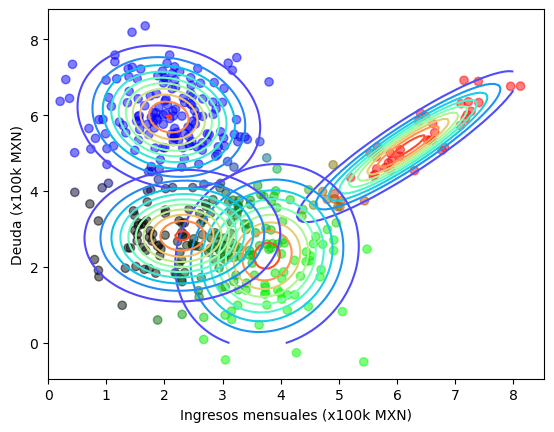

In [16]:
# Datos
plt.scatter(
    x=df['income'],
    y=df['debt'], 
    c=gmm.predict_proba(df[['income', 'debt']]),
    cmap='Accent',
    alpha=0.5
)
# Añadimos etiquetas a los ejes
plt.xlabel('Ingresos mensuales (x100k MXN)')
plt.ylabel('Deuda (x100k MXN)')

# Gaussiana 1
x = np.linspace(0, 8, 100)
y = np.linspace(0, 8, 100)
X, Y = np.meshgrid(x, y)
z = X1.pdf(np.dstack((X, Y)))
# Graficamos la función de densidad
plt.contour(X, Y, z, levels=10, cmap='rainbow')

# Gaussiana 2
x = np.linspace(0, 8, 100)
y = np.linspace(0, 8, 100)
X, Y = np.meshgrid(x, y)
z = X2.pdf(np.dstack((X, Y)))
# Graficamos la función de densidad
plt.contour(X, Y, z, levels=10, cmap='rainbow')

# Gaussiana 3
x = np.linspace(0, 8, 100)
y = np.linspace(0, 8, 100)
X, Y = np.meshgrid(x, y)
z = X3.pdf(np.dstack((X, Y)))
# Graficamos la función de densidad
plt.contour(X, Y, z, levels=10, cmap='rainbow')

# Gaussiana 4
x = np.linspace(0, 8, 100)
y = np.linspace(0, 8, 100)
X, Y = np.meshgrid(x, y)
z = X4.pdf(np.dstack((X, Y)))
# Graficamos la función de densidad
plt.contour(X, Y, z, levels=10, cmap='rainbow')

---

#### 2. Probar varios números de componentes y comparar BIC

In [17]:
import warnings
warnings.filterwarnings('ignore')

In [18]:
#BIC
ks = range(1, 10)
bics = []

for k in ks:
    gmm = GaussianMixture(n_components=k)
    gmm.fit(df[['income', 'debt']])
    bics.append(gmm.bic(df[['income', 'debt']]))

list1 = list(zip(ks, bics))
list1

[(1, np.float64(3139.7023248527153)),
 (2, np.float64(3047.383711336373)),
 (3, np.float64(2848.719674454879)),
 (4, np.float64(2879.9717941906747)),
 (5, np.float64(2916.099109990764)),
 (6, np.float64(2947.944858552475)),
 (7, np.float64(2974.076123985999)),
 (8, np.float64(3007.669527897546)),
 (9, np.float64(3043.7209972934324))]

In [19]:
min(list1, key=lambda x: x[1])

(3, np.float64(2848.719674454879))

In [20]:
#AIC
aics = []
for k in ks:
    gmm = GaussianMixture(n_components=k)
    gmm.fit(df[['income', 'debt']])
    aics.append(gmm.aic(df[['income', 'debt']]))

list2 = list(zip(ks, aics))
list2

[(1, np.float64(3119.7450021171753)),
 (2, np.float64(2941.1395695117412)),
 (3, np.float64(2780.683891655892)),
 (4, np.float64(2788.5255145020246)),
 (5, np.float64(2795.1254994311203)),
 (6, np.float64(2808.675173931118)),
 (7, np.float64(2814.5249124859256)),
 (8, np.float64(2818.0203665376143)),
 (9, np.float64(2807.5136257720155))]

In [21]:
min(list2, key=lambda x: x[1])

(3, np.float64(2780.683891655892))

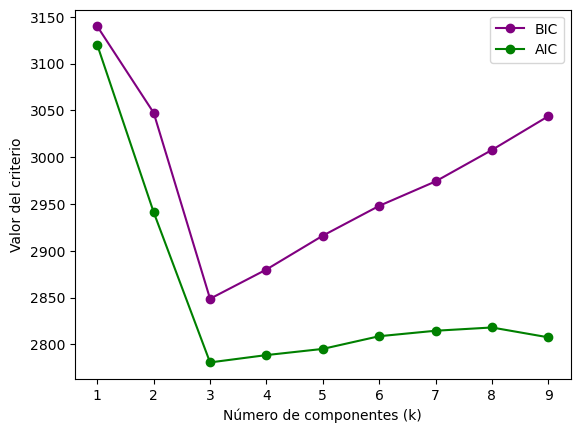

In [22]:
# Mostrar resultados
plt.plot(ks, bics, marker='o', label="BIC", color='purple')
plt.plot(ks, aics, marker='o', label="AIC", color='green')
plt.xlabel("Número de componentes (k)")
plt.ylabel("Valor del criterio")
plt.legend()
plt.show()